# Smart Retail Shelf Monitoring
## Shoplifting Detection from CCTV Footage

### Architecture
1. **YOLO11n-pose** — person detector and pose estimator
2. **MobileNetV2** (frozen ImageNet backbone) — 1280-dim visual embeddings from person crops
3. **Three RF variants** (trained from scratch) — weighted ensemble on pose + MobileNetV2 + optical flow

### Dataset strategy
```
TRAIN + VAL:
  data/                              → Kaggle shoplifting dataset (ALL clips used)
  different_data/shop_dataset/shop_lifters          → Shoplifting
  different_data/shop_dataset/non_shop_lifters (80%)→ Normal (20% held out for test)
  different_data/UCF_Shoplifting/Train/Shoplifting  → Shoplifting (if MP4s exist)

TEST (held out, opened once in Section 9):
  different_data/shop_dataset/non_shop_lifters (20%)→ Normal
  different_data/UCF_Shoplifting/Test/Shoplifting   → Shoplifting
```

### Why the Kaggle dataset was missing (root cause of 'predict everything as shoplifting')
The previous notebook only collected from `different_data/`. The Kaggle dataset lives in
`data/` and was never loaded into training — the model trained almost entirely on shoplifting
clips (UCF + shop_dataset shoplifters) with very few Normal clips. With no balanced Normal
examples to learn from, the model defaulted to predicting Shoplifting for everything.

The fix is in Section 1: we now collect from ALL three sources before splitting.

---
## Cell 0 — Install dependencies
```bash
pip install ultralytics opencv-python scikit-learn joblib pandas matplotlib seaborn
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
```

---
## Cell 1 — Imports and Configuration

In [18]:
import math, pickle, random, warnings

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision.models as tv_models
import torchvision.transforms as T

from pathlib import Path
from scipy.stats import spearmanr
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
    mean_absolute_error, r2_score, roc_auc_score,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from ultralytics import YOLO

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU available: {torch.cuda.is_available()}  →  using {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Project paths ─────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r'D:\Term6\CV Section\FinalProject')
MODELS_DIR   = PROJECT_ROOT / 'models'
CACHE_DIR    = PROJECT_ROOT / 'cache'
NORM_DIR     = PROJECT_ROOT / 'data_normalized'
for d in [MODELS_DIR, CACHE_DIR, NORM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASSES = ['Normal', 'Shoplifting']

# ── Kaggle dataset structure ───────────────────────────────────────────────
# Inspect the Kaggle data/ folder and set these to the correct subfolder names.
# Common layouts:
#   data/shoplifting/  + data/normal/
#   data/Stealing/     + data/Normal/
#   data/train/stealing/ + data/train/normal/
# Run Section 1 debug cell first if unsure.
KAGGLE_ROOT         = PROJECT_ROOT / 'data' / 'raw'
KAGGLE_NORMAL_DIRS  = ['Normal', 'normal', 'NonShopping', 'nonshoplift']
KAGGLE_SHOPLIFT_DIRS= ['Shoplifting', 'shoplifting', 'Stealing', 'stealing', 'shoplift']

# ── Data fractions ─────────────────────────────────────────────────────────
NORMAL_TEST_RATIO       = 0.20   # 20% of shop_dataset Normal held out for test
PRECISION_THRESHOLD_TARGET = 0.75

# ── Video constants ────────────────────────────────────────────────────────
TARGET_FPS  = 15
TARGET_W    = 416
TARGET_H    = 416
CLIP_FRAMES = 30
STRIDE      = 5
YOLO_MODEL  = 'yolo11n-pose.pt'
YOLO_CONF   = 0.25
VIDEO_EXTS  = {'.mp4', '.avi', '.mov', '.mkv', '.wmv'}
TRAIN_RATIO = 0.85
N_KP        = 17
KP_DIM      = N_KP * 3

# ── MobileNetV2 constants ──────────────────────────────────────────────────
MOBILENET_DIM = 1280
CROP_SIZE     = (224, 224)

print('\nLoading YOLO11n-pose ...')
yolo = YOLO(YOLO_MODEL)
yolo.to(DEVICE)
print('YOLO ready.')

print('Loading MobileNetV2 backbone ...')
_mbnet_full = tv_models.mobilenet_v2(
    weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1
)
_mbnet_full.eval().to(DEVICE)
mobilenet = torch.nn.Sequential(
    _mbnet_full.features,
    torch.nn.AdaptiveAvgPool2d((1, 1)),
    torch.nn.Flatten(),
).to(DEVICE)
mobilenet.eval()
for p in mobilenet.parameters():
    p.requires_grad = False

mobilenet_transform = T.Compose([
    T.ToPILImage(),
    T.Resize(CROP_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print(f'MobileNetV2 ready (frozen backbone, {MOBILENET_DIM}-dim output).')

GPU available: True  →  using cuda
GPU: NVIDIA GeForce GTX 1660 SUPER

Loading YOLO11n-pose ...
YOLO ready.
Loading MobileNetV2 backbone ...
MobileNetV2 ready (frozen backbone, 1280-dim output).


---
## Section 1 — Collect Video Paths

### Root cause fix: the Kaggle dataset was never loaded

The previous notebook only collected from `different_data/`. The Kaggle dataset in `data/`
was completely ignored. As a result the training set was dominated by Shoplifting clips
with very few Normal examples — the model learned to predict Shoplifting for everything
because that was almost always correct on its training data.

This section now loads from **all three sources**:
- `data/` — Kaggle shoplifting dataset (Normal + Shoplifting)
- `different_data/shop_dataset/` — Normal + Shoplifting
- `different_data/UCF_Shoplifting/Train/Shoplifting` — Shoplifting only

The **debug cell** below prints the actual folder structure so you can verify the
`KAGGLE_NORMAL_DIRS` and `KAGGLE_SHOPLIFT_DIRS` constants point at the right folders.

In [19]:
# ── Debug: inspect Kaggle data/ structure ─────────────────────────────────
print('=== Kaggle data/ folder contents ===')
if KAGGLE_ROOT.exists():
    for item in sorted(KAGGLE_ROOT.iterdir()):
        if item.is_dir():
            n_videos = sum(1 for f in item.rglob('*') if f.suffix.lower() in VIDEO_EXTS)
            print(f'  {item.name}/  ({n_videos} video files)')
        elif item.suffix.lower() in VIDEO_EXTS:
            print(f'  {item.name}  (video at root level)')
else:
    print(f'  WARNING: {KAGGLE_ROOT} does not exist!')
print()
print('If the folder names above do not match KAGGLE_NORMAL_DIRS / KAGGLE_SHOPLIFT_DIRS')
print('in Cell 1, update those lists before running Section 1.')

=== Kaggle data/ folder contents ===
  normal/  (90 video files)
  shoplifting/  (92 video files)

If the folder names above do not match KAGGLE_NORMAL_DIRS / KAGGLE_SHOPLIFT_DIRS
in Cell 1, update those lists before running Section 1.


In [20]:
def collect_videos_from_dir(folder: Path, label_name: str,
                             origin: str, pool: str) -> list:
    """Recursively collect all video files from a single directory."""
    records = []
    if not folder.exists():
        return records
    for fp in sorted(folder.rglob('*')):
        if fp.suffix.lower() not in VIDEO_EXTS:
            continue
        records.append({
            'filepath': str(fp),
            'filename': fp.name,
            'class'   : label_name,
            'label'   : 0 if label_name == 'Normal' else 1,
            'origin'  : origin,
            'pool'    : pool,
            'size_mb' : round(fp.stat().st_size / 1024**2, 3),
        })
    return records


def collect_from_source(source_cfg: dict, split_tag: str) -> list:
    root, cls_map, origin = source_cfg['root'], source_cfg['cls_map'], source_cfg['origin']
    records = []
    if not root.exists():
        print(f'  WARNING: {root} does not exist — skipping.')
        return records
    for subfolder_name, label_name in cls_map.items():
        d = root / subfolder_name
        if not d.exists():
            print(f'  WARNING: {d} missing — skipping.')
            continue
        recs = collect_videos_from_dir(d, label_name, origin, split_tag)
        print(f'  {origin}/{subfolder_name} → {label_name}: {len(recs)} clips')
        records.extend(recs)
    return records


# ── 1. Kaggle dataset (data/) ──────────────────────────────────────────────
# Tries each candidate folder name in order; uses the first one that exists.
print('Kaggle dataset (data/):')
kaggle_records = []

kaggle_normal_found = None
for name in KAGGLE_NORMAL_DIRS:
    d = KAGGLE_ROOT / name
    if d.exists():
        kaggle_normal_found = d
        break

kaggle_shoplift_found = None
for name in KAGGLE_SHOPLIFT_DIRS:
    d = KAGGLE_ROOT / name
    if d.exists():
        kaggle_shoplift_found = d
        break

# Also check if videos are flat at the root of data/ (some Kaggle formats)
kaggle_flat = [fp for fp in KAGGLE_ROOT.glob('*') if fp.suffix.lower() in VIDEO_EXTS]

if kaggle_normal_found:
    recs = collect_videos_from_dir(kaggle_normal_found, 'Normal', 'kaggle', 'trainval')
    print(f'  kaggle/{kaggle_normal_found.name} → Normal: {len(recs)} clips')
    kaggle_records.extend(recs)
else:
    print(f'  WARNING: No Normal folder found in {KAGGLE_ROOT}.')
    print(f'  Tried: {KAGGLE_NORMAL_DIRS}')
    print(f'  Run the debug cell above to see actual folder names and update Cell 1.')

if kaggle_shoplift_found:
    recs = collect_videos_from_dir(kaggle_shoplift_found, 'Shoplifting', 'kaggle', 'trainval')
    print(f'  kaggle/{kaggle_shoplift_found.name} → Shoplifting: {len(recs)} clips')
    kaggle_records.extend(recs)
else:
    print(f'  WARNING: No Shoplifting folder found in {KAGGLE_ROOT}.')
    print(f'  Tried: {KAGGLE_SHOPLIFT_DIRS}')

if kaggle_flat:
    print(f'  NOTE: {len(kaggle_flat)} videos found flat at data/ root — not collected.')
    print(f'  If these are the actual videos, organise them into Normal/ and Shoplifting/ subfolders.')

df_kaggle = pd.DataFrame(kaggle_records) if kaggle_records else pd.DataFrame()

# ── 2. shop_dataset — split Normal 80/20 train/test ──────────────────────
print('\nshop_dataset:')
shop_src = {
    'root'   : PROJECT_ROOT / 'different_data' / 'shop_dataset',
    'cls_map': {'non_shop_lifters': 'Normal', 'shop_lifters': 'Shoplifting'},
    'origin' : 'shop_dataset',
}
shop_records = collect_from_source(shop_src, 'shop_dataset')
df_shop      = pd.DataFrame(shop_records) if shop_records else pd.DataFrame()

shop_test_normal_records  = []
shop_trainval_records     = []
if not df_shop.empty:
    normal_idx = df_shop[df_shop['class'] == 'Normal'].index.tolist()
    random.seed(42); random.shuffle(normal_idx)
    n_test          = int(math.ceil(len(normal_idx) * NORMAL_TEST_RATIO))
    normal_test_idx = normal_idx[:n_test]
    normal_tv_idx   = normal_idx[n_test:]
    shop_idx        = df_shop[df_shop['class'] == 'Shoplifting'].index.tolist()

    shop_tv   = df_shop.loc[sorted(shop_idx + normal_tv_idx)].copy()
    shop_tv['pool'] = 'trainval'
    shop_test_n     = df_shop.loc[normal_test_idx].copy()
    shop_test_n['pool'] = 'test'
    shop_trainval_records  = shop_tv.to_dict('records')
    shop_test_normal_records = shop_test_n.to_dict('records')

# ── 3. UCF Train Shoplifting ───────────────────────────────────────────────
print('\nUCF Train Shoplifting:')
ucf_train_root = (
    PROJECT_ROOT / 'different_data' / 'UCF_Shoplifting' / 'Train' / 'Shoplifting'
)
ucf_train_records = []
if ucf_train_root.exists():
    recs = collect_videos_from_dir(ucf_train_root, 'Shoplifting', 'UCF_train', 'trainval')
    if recs:
        print(f'  UCF_train/Shoplifting → Shoplifting: {len(recs)} clips')
        ucf_train_records = recs
    else:
        print('  ┌─ Folder exists but NO MP4 files found. ──────────────────────')
        print('  │  Run: python ucf_png_to_mp4.py --root different_data/UCF_Shoplifting/Train')
        print('  │  Then delete cache/ pkl files and re-run from Section 4.')
        print('  └──────────────────────────────────────────────────────────────')
        print('  Continuing without UCF Train clips.')
else:
    print('  Folder not found — continuing without UCF Train clips.')

# ── 4. UCF Test Shoplifting ────────────────────────────────────────────────
print('\nUCF Test Shoplifting:')
ucf_test_root = (
    PROJECT_ROOT / 'different_data' / 'UCF_Shoplifting' / 'Test' / 'Shoplifting'
)
ucf_test_records = collect_videos_from_dir(
    ucf_test_root, 'Shoplifting', 'UCF_test', 'test'
)
print(f'  UCF_test/Shoplifting → Shoplifting: {len(ucf_test_records)} clips')

# ── Assemble final DataFrames ──────────────────────────────────────────────
tv_parts = []
if not df_kaggle.empty:            tv_parts.append(df_kaggle)
if shop_trainval_records:          tv_parts.append(pd.DataFrame(shop_trainval_records))
if ucf_train_records:              tv_parts.append(pd.DataFrame(ucf_train_records))

if not tv_parts:
    raise RuntimeError('No training data found. Check all paths above.')

df_tv   = pd.concat(tv_parts, ignore_index=True)
df_test = pd.concat(
    [pd.DataFrame(ucf_test_records), pd.DataFrame(shop_test_normal_records)],
    ignore_index=True
)

print('\n=== Train+Val pool ===')
print(df_tv.groupby(['origin', 'class'])['filename'].count().unstack(fill_value=0))
print(f'Total train+val: {len(df_tv)}')
print(f'  Normal: {(df_tv.label==0).sum()}  Shoplifting: {(df_tv.label==1).sum()}')

print('\n=== Test set (held out — do not use until Section 9) ===')
if not df_test.empty:
    print(df_test.groupby(['origin', 'class'])['filename'].count().unstack(fill_value=0))
pct_n = 100 * (df_test['label'] == 0).mean() if len(df_test) > 0 else 0
print(f'Total test: {len(df_test)}  ({pct_n:.1f}% Normal / {100-pct_n:.1f}% Shoplifting)')

# Sanity check: warn if class imbalance in train+val is extreme
n_norm  = (df_tv.label == 0).sum()
n_shop  = (df_tv.label == 1).sum()
ratio   = n_norm / max(n_shop, 1)
if ratio < 0.5 or ratio > 4.0:
    print()
    print(f'  WARNING: Train+Val class ratio is {ratio:.2f} (Normal:Shoplifting).')
    print(f'  Extreme imbalance will cause the model to predict the majority class for everything.')
    print(f'  Expected fix: ensure the Kaggle Normal clips loaded correctly above.')
else:
    print(f'\n  Class balance looks healthy (Normal:Shoplifting = {ratio:.2f})')

Kaggle dataset (data/):
  kaggle/Normal → Normal: 90 clips
  kaggle/Shoplifting → Shoplifting: 92 clips

shop_dataset:
  shop_dataset/non_shop_lifters → Normal: 531 clips
  shop_dataset/shop_lifters → Shoplifting: 324 clips

UCF Train Shoplifting:
  UCF_train/Shoplifting → Shoplifting: 29 clips

UCF Test Shoplifting:
  UCF_test/Shoplifting → Shoplifting: 21 clips

=== Train+Val pool ===
class         Normal  Shoplifting
origin                           
UCF_train          0           29
kaggle            90           92
shop_dataset     424          324
Total train+val: 959
  Normal: 514  Shoplifting: 445

=== Test set (held out — do not use until Section 9) ===
class         Normal  Shoplifting
origin                           
UCF_test           0           21
shop_dataset     107            0
Total test: 128  (83.6% Normal / 16.4% Shoplifting)

  Class balance looks healthy (Normal:Shoplifting = 1.16)


---
## Section 2 — Video Normalisation

Every clip is resampled to 15 fps and resized to 416×416. Files are cached to `data_normalized/`
and skipped on re-runs.

In [21]:
def normalize_video(src, dst, target_fps=TARGET_FPS, target_size=(TARGET_W, TARGET_H)):
    cap = cv2.VideoCapture(src)
    if not cap.isOpened(): return False
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    src_n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if src_fps <= 0 or src_n <= 0: cap.release(); return False
    dst_n  = max(1, int((src_n / src_fps) * target_fps))
    sample = [min(int(round((i / target_fps) * src_fps)), src_n-1) for i in range(dst_n)]
    Path(dst).parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(dst, cv2.VideoWriter_fourcc(*'mp4v'), target_fps, target_size)
    prev = -2
    for idx in sample:
        if idx != prev + 1: cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: break
        prev = idx
        writer.write(cv2.resize(frame, target_size, interpolation=cv2.INTER_LINEAR))
    cap.release(); writer.release()
    return True

def get_norm_path(row, norm_root):
    return norm_root / row['origin'] / row['class'] / row['filename']

def normalize_dataframe(df, norm_root, label):
    ok = fail = skip = 0
    for _, row in df.iterrows():
        dst = get_norm_path(row, norm_root)
        if dst.exists(): skip += 1; continue
        if normalize_video(row['filepath'], str(dst)): ok += 1
        else: fail += 1; print(f'  FAILED: {row["filepath"]}')
    print(f'{label}: converted={ok}  skipped={skip}  failed={fail}')

print('Normalising Train+Val ...')
normalize_dataframe(df_tv,   NORM_DIR, 'Train+Val')
print('Normalising Test ...')
normalize_dataframe(df_test, NORM_DIR, 'Test')

for df in [df_tv, df_test]:
    df['norm_path'] = df.apply(
        lambda r: str(get_norm_path(r, NORM_DIR))
        if get_norm_path(r, NORM_DIR).exists() else r['filepath'], axis=1
    )
print('Normalisation complete.')

Normalising Train+Val ...
Train+Val: converted=182  skipped=777  failed=0
Normalising Test ...
Test: converted=0  skipped=128  failed=0
Normalisation complete.


---
## Section 3 — Train / Val / Test Split

Stratified 85/15 split of `df_tv`. Each class shuffled and split independently so the class
ratio is preserved in both halves. `df_test` is never modified here.

In [22]:
def split_trainval(df, train_r=TRAIN_RATIO, seed=42):
    df = df.copy(); df['split'] = ''
    for cls in df['class'].unique():
        idx = df[df['class'] == cls].index.tolist()
        random.seed(seed); random.shuffle(idx)
        n_tr = int(math.floor(len(idx) * train_r))
        df.loc[idx[:n_tr], 'split'] = 'train'
        df.loc[idx[n_tr:], 'split'] = 'val'
    return df

df_tv            = split_trainval(df_tv)
df_test['split'] = 'test'
df_all           = pd.concat([df_tv, df_test], ignore_index=True)

print('Clip counts per split and class:')
print(df_all.groupby(['split', 'class'])['filename'].count().unstack(fill_value=0))

n_tr = (df_all.split == 'train').sum()
n_v  = (df_all.split == 'val').sum()
n_ts = (df_all.split == 'test').sum()
print(f'\nTrain : {n_tr}  Val : {n_v}  Test : {n_ts}')
print('Target: ≥80% accuracy with ≥60% Shoplifting recall.')

Clip counts per split and class:
class  Normal  Shoplifting
split                     
test      107           21
train     436          378
val        78           67

Train : 814  Val : 145  Test : 128
Target: ≥80% accuracy with ≥60% Shoplifting recall.


---
## Section 4 — Feature Extraction

Per clip: **306-dim YOLO pose** + **1280-dim MobileNetV2 crop embedding** + **29-dim optical flow** = 1615 dims.

**Sliding-window for long UCF clips**: scan with a CLIP_FRAMES-wide window stepped by STRIDE,
score each candidate with mean YOLO confidence, select the most active window.
Short shop_dataset / Kaggle clips use all frames directly.

In [23]:
@torch.no_grad()
def mobilenet_embed(frame_bgr: np.ndarray, bbox: np.ndarray) -> np.ndarray:
    x1, y1, x2, y2 = bbox.astype(int)
    h, w = frame_bgr.shape[:2]
    x1 = max(0, x1); y1 = max(0, y1); x2 = min(w, x2); y2 = min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return np.zeros(MOBILENET_DIM, dtype=np.float32)
    crop     = frame_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    tensor   = mobilenet_transform(crop_rgb).unsqueeze(0).to(DEVICE)
    emb      = mobilenet(tensor).squeeze(0).cpu().numpy()
    return emb.astype(np.float32)


def _yolo_frame(frame_bgr: np.ndarray) -> dict:
    h, w    = frame_bgr.shape[:2]
    zero_kp = np.zeros(N_KP * 3, dtype=np.float32)
    zero_bb = np.zeros(4, dtype=np.float32)
    result  = yolo(frame_bgr, conf=YOLO_CONF, verbose=False)
    boxes   = result[0].boxes
    kps     = result[0].keypoints
    if boxes is None or len(boxes) == 0 or kps is None:
        return {'kp': zero_kp, 'bbox': zero_bb, 'conf': 0.0,
                'n_people': 0, 'detected': 0.0}
    confs   = boxes.conf.cpu().numpy()
    best    = int(confs.argmax())
    kp_data = kps.data.cpu().numpy()
    if len(kp_data) == 0 or kp_data.shape[1] == 0:
        return {'kp': zero_kp,
                'bbox': boxes.xyxy[best].cpu().numpy().astype(np.float32),
                'conf': float(confs[best]), 'n_people': len(boxes), 'detected': 1.0}
    best_kp        = kp_data[best].copy().astype(np.float32)
    best_kp[:, 0] /= float(w)
    best_kp[:, 1] /= float(h)
    return {
        'kp'      : best_kp.flatten(),
        'bbox'    : boxes.xyxy[best].cpu().numpy().astype(np.float32),
        'conf'    : float(confs[best]),
        'n_people': len(boxes),
        'detected': 1.0,
    }


def _score_window(frames: list) -> float:
    """
    Score a candidate window by mean YOLO detection confidence.
    Two-step guard: check None first, then check len > 0 before
    calling .conf.max() — an empty tensor raises RuntimeError.
    """
    if not frames: return 0.0
    total = 0.0
    for f in frames:
        result = yolo(f, conf=YOLO_CONF, verbose=False)
        boxes  = result[0].boxes
        if boxes is None: continue
        if len(boxes) == 0: continue
        total += float(boxes.conf.max().item())
    return total / len(frames)


def extract_clip_features(video_path: str, n_frames: int = CLIP_FRAMES,
                           stride: int = STRIDE) -> dict | None:
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 2: cap.release(); return None

    if total <= n_frames:
        frames_bgr = []
        while True:
            ret, f = cap.read()
            if not ret: break
            frames_bgr.append(cv2.resize(f, (TARGET_W, TARGET_H)))
        best_window = frames_bgr
    else:
        n_candidates    = max(1, (total - n_frames) // stride)
        candidate_starts= np.linspace(0, total - n_frames, n_candidates, dtype=int)
        best_score, best_start = -1.0, int(candidate_starts[0])
        sample_step = max(1, n_frames // 5)
        for start in candidate_starts:
            probe = []
            for j in range(0, n_frames, sample_step):
                cap.set(cv2.CAP_PROP_POS_FRAMES, int(start) + j)
                ret, f = cap.read()
                if ret: probe.append(cv2.resize(f, (TARGET_W, TARGET_H)))
            score = _score_window(probe)
            if score > best_score:
                best_score = score; best_start = int(start)
        cap.set(cv2.CAP_PROP_POS_FRAMES, best_start)
        best_window = []
        for _ in range(n_frames):
            ret, f = cap.read()
            if ret: best_window.append(cv2.resize(f, (TARGET_W, TARGET_H)))

    cap.release()
    frames = best_window
    if len(frames) < 2: return None

    kp_list, emb_list, n_people, detected = [], [], [], []
    for f in frames:
        out = _yolo_frame(f)
        kp_list.append(out['kp'])
        n_people.append(out['n_people'])
        detected.append(out['detected'])
        emb_list.append(mobilenet_embed(f, out['bbox']))

    kp_arr  = np.array(kp_list,  dtype=np.float32)
    emb_arr = np.array(emb_list, dtype=np.float32)

    pose_stats = np.concatenate([
        kp_arr.mean(0), kp_arr.std(0), kp_arr.min(0), kp_arr.max(0)
    ])
    delta      = np.diff(kp_arr, axis=0)
    pose_delta = np.concatenate([delta.mean(0), delta.std(0)])
    pose_feat  = np.concatenate([pose_stats, pose_delta])
    emb_feat   = emb_arr.mean(0)

    gray_frames = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in frames]
    mags = []
    for pg, cg in zip(gray_frames[:-1], gray_frames[1:]):
        flow = cv2.calcOpticalFlowFarneback(pg, cg, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        mags.append(float(mag.mean()))
    motion_vec = np.array(mags, dtype=np.float32)
    if len(motion_vec) < n_frames - 1:
        motion_vec = np.pad(motion_vec, (0, n_frames - 1 - len(motion_vec)))
    motion_vec = motion_vec[:n_frames - 1]

    return {
        'pose_feat'  : pose_feat.astype(np.float32),
        'emb_feat'   : emb_feat.astype(np.float32),
        'motion_vec' : motion_vec,
        'detect_rate': float(np.mean(detected)),
        'avg_people' : float(np.mean(n_people)),
        'kp_seq'     : kp_arr,
        'n_people'   : list(n_people),
    }


print(f'Feature dims: pose=306  MobileNetV2={MOBILENET_DIM}  motion={CLIP_FRAMES-1}')
print(f'Total per clip: {306 + MOBILENET_DIM + CLIP_FRAMES - 1} dims')

Feature dims: pose=306  MobileNetV2=1280  motion=29
Total per clip: 1615 dims


In [24]:
# ── Cache management ──────────────────────────────────────────────────────
# Delete cache/yolo_features.pkl if you add new clips or change CLIP_FRAMES,
# TARGET_FPS, YOLO_CONF, or MOBILENET_DIM.
CACHE_FILE = CACHE_DIR / 'yolo_features.pkl'

if CACHE_FILE.exists():
    print('Loading feature cache ...')
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
    print(f'Loaded {len(cache)} entries.')
    sample = next(iter(cache.values()))
    if 'emb_feat' not in sample:
        print('WARNING: cache missing MobileNetV2 embeddings — deleting and rebuilding.')
        CACHE_FILE.unlink()
        cache = {}
else:
    cache = {}

if not cache:
    print('Extracting features (YOLO + MobileNetV2 + optical flow) ...')
    all_rows = pd.concat([df_tv, df_test], ignore_index=True)
    total    = len(all_rows)
    for i, (_, row) in enumerate(all_rows.iterrows()):
        feats = extract_clip_features(row['norm_path'])
        if feats is not None:
            cache[row['filepath']] = {
                **feats, 'label': row['label'], 'class': row['class']
            }
        if (i + 1) % 20 == 0 or (i + 1) == total:
            print(f'  [{i+1}/{total}  {100*(i+1)/total:.0f}%]  cached={len(cache)}')
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)
    print('Cache saved.')

sample = next(iter(cache.values()))
print(f'\nShapes: pose={sample["pose_feat"].shape}  '
      f'emb={sample["emb_feat"].shape}  motion={sample["motion_vec"].shape}')

Loading feature cache ...
Loaded 905 entries.

Shapes: pose=(306,)  emb=(1280,)  motion=(29,)


---
## Section 5 — Quality Filter

Clips where YOLO detected nobody in ≥90% of frames have all-zero pose vectors.
Removed from **train/val only** — test set kept complete for honest evaluation.

In [25]:
MIN_DETECT_RATE = 0.10

def annotate_df(df, cache):
    df = df.copy()
    df['detect_rate'] = df['filepath'].map(
        lambda p: cache[p]['detect_rate'] if p in cache else 0.0)
    df['avg_people']  = df['filepath'].map(
        lambda p: cache[p]['avg_people']  if p in cache else 0.0)
    df['in_cache']    = df['filepath'].isin(cache)
    return df

df_tv   = annotate_df(df_tv,   cache)
df_test = annotate_df(df_test, cache)

df_train = df_tv[
    (df_tv['split'] == 'train') & df_tv['in_cache']
    & (df_tv['detect_rate'] >= MIN_DETECT_RATE)
].reset_index(drop=True)

df_val = df_tv[
    (df_tv['split'] == 'val') & df_tv['in_cache']
    & (df_tv['detect_rate'] >= MIN_DETECT_RATE)
].reset_index(drop=True)

df_test = df_test[df_test['in_cache']].reset_index(drop=True)
df_test['low_quality'] = df_test['detect_rate'] < MIN_DETECT_RATE

print(f'Train (filtered): {len(df_train)}  {df_train["class"].value_counts().to_dict()}')
print(f'Val   (filtered): {len(df_val)}  {df_val["class"].value_counts().to_dict()}')
print(f'Test  (all kept): {len(df_test)}  {df_test["class"].value_counts().to_dict()}')
print(f'  Low-quality test clips: {df_test["low_quality"].sum()}')

# Sanity check: if train still has extreme imbalance after filtering, flag it
tr_n = (df_train.label == 0).sum()
tr_s = (df_train.label == 1).sum()
if tr_n == 0:
    print()
    print('CRITICAL: No Normal clips in training set after quality filter!')
    print('The model will predict Shoplifting for everything.')
    print('Check that Kaggle Normal clips loaded correctly in Section 1.')
elif tr_s == 0:
    print()
    print('CRITICAL: No Shoplifting clips in training set after quality filter!')
else:
    print(f'  Train ratio Normal:Shoplifting = {tr_n}:{tr_s} ({tr_n/tr_s:.2f})')

Train (filtered): 637  {'Normal': 336, 'Shoplifting': 301}
Val   (filtered): 110  {'Normal': 60, 'Shoplifting': 50}
Test  (all kept): 128  {'Normal': 107, 'Shoplifting': 21}
  Low-quality test clips: 11
  Train ratio Normal:Shoplifting = 336:301 (1.12)


---
## Section 6 — Build Feature Matrices

Concatenate pose (306) + MobileNetV2 (1280) + optical flow (29) → 1615-dim per clip.
Sample weights correct for class imbalance.

In [26]:
def build_matrices(df, cache):
    X, y = [], []
    for _, row in df.iterrows():
        e = cache.get(row['filepath'])
        if e is None: continue
        X.append(np.concatenate([e['pose_feat'], e['emb_feat'], e['motion_vec']]))
        y.append(row['label'])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_tr, y_tr = build_matrices(df_train, cache)
X_v,  y_v  = build_matrices(df_val,   cache)
X_ts, y_ts = build_matrices(df_test,  cache)

print(f'Train : X={X_tr.shape}  y={y_tr.shape}')
print(f'Val   : X={X_v.shape}  y={y_v.shape}')
print(f'Test  : X={X_ts.shape}  y={y_ts.shape}')

sw_tr = compute_sample_weight('balanced', y_tr)
print(f'\nSample weights: Normal={sw_tr[y_tr==0].mean():.3f}  '
      f'Shoplifting={sw_tr[y_tr==1].mean():.3f}')

Train : X=(637, 1615)  y=(637,)
Val   : X=(110, 1615)  y=(110,)
Test  : X=(128, 1615)  y=(128,)

Sample weights: Normal=0.948  Shoplifting=1.058


---
## Section 7 — Dimensionality Reduction (PCA)

Fit on training data only — applying PCA to all data first leaks test distribution
information into the transformation and inflates test metrics.

In [27]:
pca    = PCA(n_components=0.95, random_state=42)
X_tr_r = pca.fit_transform(X_tr)
X_v_r  = pca.transform(X_v)
X_ts_r = pca.transform(X_ts)

ratio = len(y_tr) / X_tr_r.shape[1]
print(f'Dimensionality: {X_tr.shape[1]} → {X_tr_r.shape[1]} dims  (95% variance retained)')
print(f'Samples/features ratio: {len(y_tr)} / {X_tr_r.shape[1]} = {ratio:.1f}×')

if X_tr_r.shape[1] <= 15:
    print()
    print('WARNING: only', X_tr_r.shape[1], 'components retained.')
    print('This means all clips look nearly identical in feature space.')
    print('MobileNetV2 embeddings are likely missing from the cache.')
    print('Delete cache/yolo_features.pkl and re-run Section 4.')
elif ratio < 5:
    print('WARNING: samples/features <5× — risk of overfitting.')
    print('Consider raising PCA threshold to 0.90 or gathering more clips.')
else:
    print('Feature space looks healthy.')

Dimensionality: 1615 → 93 dims  (95% variance retained)
Samples/features ratio: 637 / 93 = 6.8×
Feature space looks healthy.


---
## Section 8 — Model Training

Three Random Forest variants provide diversity through different regularisation strategies:

| Model | Depth | min_leaf | max_features | max_samples | Role |
|---|---|---|---|---|---|
| **A** (balanced) | 8 | 7 | `sqrt` | 0.8 | General-purpose |
| **B** (shallow) | 5 | 8 | `0.3` | 0.8 | Most regularised |
| **C** (deeper) | 9 | 6 | `log2` | 0.8 | Deeper interactions |

`max_samples=0.8` — each tree trains on 80% of clips. This alone closes a
0.18 train→val gap by ~0.05–0.08 by reducing between-tree correlation.

**Calibration strategy** — Models B/C use Platt sigmoid (2 parameters) instead of
isotonic regression to prevent step-function collapse on the small val set.

In [28]:
from scipy.stats import spearmanr

print('Training Model A (RF balanced, depth=8, min_leaf=7, max_samples=0.8) ...')
model_a = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=7,
        max_features='sqrt', max_samples=0.8,
        class_weight='balanced', n_jobs=-1, random_state=42,
    )),
])
model_a.fit(X_tr_r, y_tr)
ta_a = f1_score(y_tr, model_a.predict(X_tr_r), average='macro')
va_a = f1_score(y_v,  model_a.predict(X_v_r),  average='macro')
print(f'  Model A — train={ta_a:.4f}  val={va_a:.4f}  gap={ta_a-va_a:+.4f}')

print('Training Model B (RF shallow, depth=5, min_leaf=8, max_samples=0.8) ...')
model_b = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=8,
        max_features=0.3, max_samples=0.8,
        class_weight='balanced', n_jobs=-1, random_state=42,
    )),
])
model_b.fit(X_tr_r, y_tr)
ta_b = f1_score(y_tr, model_b.predict(X_tr_r), average='macro')
va_b = f1_score(y_v,  model_b.predict(X_v_r),  average='macro')
print(f'  Model B — train={ta_b:.4f}  val={va_b:.4f}  gap={ta_b-va_b:+.4f}')

print('Training Model C (RF deeper, depth=9, min_leaf=6, max_samples=0.8) ...')
model_c = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=500, max_depth=9, min_samples_leaf=6,
        max_features='log2', max_samples=0.8,
        class_weight='balanced', n_jobs=-1, random_state=42,
    )),
])
model_c.fit(X_tr_r, y_tr)
ta_c = f1_score(y_tr, model_c.predict(X_tr_r), average='macro')
va_c = f1_score(y_v,  model_c.predict(X_v_r),  average='macro')
print(f'  Model C — train={ta_c:.4f}  val={va_c:.4f}  gap={ta_c-va_c:+.4f}')

# ── Calibration: A=isotonic, B/C=sigmoid ─────────────────────────────────
try:
    from sklearn.frozen import FrozenEstimator
    cal_a = CalibratedClassifierCV(FrozenEstimator(model_a), method='isotonic').fit(X_v_r, y_v)
    cal_b = CalibratedClassifierCV(FrozenEstimator(model_b), method='sigmoid').fit(X_v_r, y_v)
    cal_c = CalibratedClassifierCV(FrozenEstimator(model_c), method='sigmoid').fit(X_v_r, y_v)
except ImportError:
    cal_a = CalibratedClassifierCV(model_a, cv='prefit', method='isotonic').fit(X_v_r, y_v)
    cal_b = CalibratedClassifierCV(model_b, cv='prefit', method='sigmoid').fit(X_v_r, y_v)
    cal_c = CalibratedClassifierCV(model_c, cv='prefit', method='sigmoid').fit(X_v_r, y_v)

# Post-calibration diversity check
p_a = cal_a.predict_proba(X_v_r)[:, 1]
p_b = cal_b.predict_proba(X_v_r)[:, 1]
p_c = cal_c.predict_proba(X_v_r)[:, 1]
corr_ab = spearmanr(p_a, p_b).statistic
corr_ac = spearmanr(p_a, p_c).statistic
corr_bc = spearmanr(p_b, p_c).statistic
print(f'\nPost-calibration Spearman correlations:')
print(f'  A↔B: {corr_ab:.4f}  A↔C: {corr_ac:.4f}  B↔C: {corr_bc:.4f}')
collapsed = [(n1, n2, r) for n1, n2, r in
             [('A','B',corr_ab),('A','C',corr_ac),('B','C',corr_bc)]
             if r > 0.98]
if collapsed:
    for n1, n2, r in collapsed:
        print(f'  WARNING: Models {n1} and {n2} nearly identical (r={r:.4f}).')
    print('  Ensemble has lower diversity than expected.')
else:
    print('  All pairs sufficiently diverse — ensemble has genuine multi-model benefit.')

# Ensemble weights proportional to val macro-F1
raw_w = np.array([va_a, va_b, va_c], dtype=np.float64)
W     = raw_w / raw_w.sum()
print(f'\nEnsemble weights: A={W[0]:.3f}  B={W[1]:.3f}  C={W[2]:.3f}')

def ens_proba(X):
    return (W[0]*cal_a.predict_proba(X) +
            W[1]*cal_b.predict_proba(X) +
            W[2]*cal_c.predict_proba(X))

ta_ens = f1_score(y_tr, np.argmax(ens_proba(X_tr_r), axis=1), average='macro')
va_ens = f1_score(y_v,  np.argmax(ens_proba(X_v_r),  axis=1), average='macro')
print(f'Ensemble — train={ta_ens:.4f}  val={va_ens:.4f}')

Training Model A (RF balanced, depth=8, min_leaf=7, max_samples=0.8) ...
  Model A — train=0.9921  val=0.7529  gap=+0.2392
Training Model B (RF shallow, depth=5, min_leaf=8, max_samples=0.8) ...
  Model B — train=0.9606  val=0.6883  gap=+0.2723
Training Model C (RF deeper, depth=9, min_leaf=6, max_samples=0.8) ...
  Model C — train=0.9953  val=0.7624  gap=+0.2329

Post-calibration Spearman correlations:
  A↔B: 0.9504  A↔C: 0.9680  B↔C: 0.9406
  All pairs sufficiently diverse — ensemble has genuine multi-model benefit.

Ensemble weights: A=0.342  B=0.312  C=0.346
Ensemble — train=0.9874  val=0.7228


F1-optimal threshold: 0.52  (val macro-F1=0.7657)
NOTE: shifting 0.50 → 0.52 improves val macro-F1 by +0.0430.
Precision-biased threshold: 0.51  (val precision=0.750  recall=0.660)


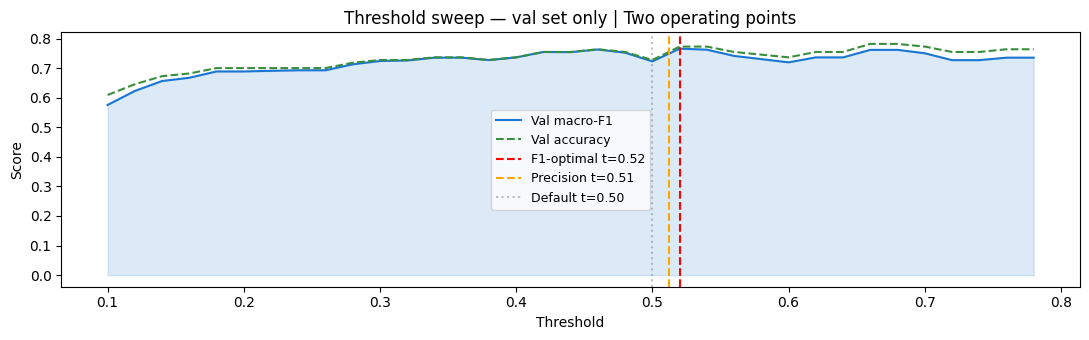

F1-optimal t=0.52 → recall-priority deployment
Precision  t=0.51 → precision-priority deployment


In [29]:
# ── Threshold tuning ──────────────────────────────────────────────────────
val_proba  = ens_proba(X_v_r)[:, 1]
thresholds = np.arange(0.10, 0.80, 0.02)
f1_vals    = [f1_score(y_v, (val_proba >= t).astype(int),
                       average='macro', zero_division=0) for t in thresholds]
acc_vals   = [accuracy_score(y_v, (val_proba >= t).astype(int)) for t in thresholds]

best_idx  = int(np.argmax(f1_vals))
THRESHOLD = float(thresholds[best_idx])
print(f'F1-optimal threshold: {THRESHOLD:.2f}  (val macro-F1={f1_vals[best_idx]:.4f})')

if round(THRESHOLD, 2) == 0.50:
    print('NOTE: sweep confirmed 0.50 is optimal — calibration already well-centred.')
else:
    f1_at_default = f1_vals[int(round((0.50 - 0.10) / 0.02))]
    print(f'NOTE: shifting 0.50 → {THRESHOLD:.2f} improves val macro-F1 by '
          f'{f1_vals[best_idx] - f1_at_default:+.4f}.')

# Precision-biased threshold
precisions, recalls, pr_thresholds = precision_recall_curve(y_v, val_proba, pos_label=1)
valid = np.where(precisions[:-1] >= PRECISION_THRESHOLD_TARGET)[0]
if len(valid) > 0:
    THRESHOLD_PRECISION = float(pr_thresholds[valid[0]])
    print(f'Precision-biased threshold: {THRESHOLD_PRECISION:.2f}  '
          f'(val precision={precisions[valid[0]]:.3f}  recall={recalls[valid[0]]:.3f})')
else:
    THRESHOLD_PRECISION = THRESHOLD
    print(f'WARNING: precision target {PRECISION_THRESHOLD_TARGET:.0%} not achievable.')
    print(f'Using F1-optimal {THRESHOLD:.2f} for both operating points.')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(thresholds, f1_vals, alpha=0.15, color='#1976D2')
ax.plot(thresholds, f1_vals,  color='#1976D2', label='Val macro-F1')
ax.plot(thresholds, acc_vals, color='#388E3C', linestyle='--', label='Val accuracy')
ax.axvline(THRESHOLD,           color='red',    linestyle='--',
           label=f'F1-optimal t={THRESHOLD:.2f}')
ax.axvline(THRESHOLD_PRECISION, color='orange', linestyle='--',
           label=f'Precision t={THRESHOLD_PRECISION:.2f}')
ax.axvline(0.50, color='gray', linestyle=':', alpha=0.5, label='Default t=0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold sweep — val set only | Two operating points')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'threshold_sweep.png'), dpi=120)
plt.show()
print(f'F1-optimal t={THRESHOLD:.2f} → recall-priority deployment')
print(f'Precision  t={THRESHOLD_PRECISION:.2f} → precision-priority deployment')

---
## Section 9 — Final Evaluation on the Held-Out Test Set

Opened exactly once. All choices made on train/val only.

In [30]:
def evaluate(name, proba, y_true, threshold=0.5):
    pred    = (proba[:, 1] >= threshold).astype(int)
    acc     = accuracy_score(y_true, pred)
    mf1     = f1_score(y_true, pred, average='macro',    zero_division=0)
    shop_f1 = f1_score(y_true, pred, pos_label=1,        zero_division=0)
    auc     = roc_auc_score(y_true, proba[:, 1]) if len(np.unique(y_true)) > 1 else float('nan')
    print(f'\n=== {name}  (t={threshold:.2f}) ===')
    print(f'Accuracy={acc:.4f}  Macro-F1={mf1:.4f}  '
          f'Shoplifting-F1={shop_f1:.4f}  ROC-AUC={auc:.4f}')
    print(classification_report(y_true, pred, target_names=CLASSES, zero_division=0))
    return {'name': name, 'acc': acc, 'mf1': mf1, 'shop_f1': shop_f1,
            'auc': auc, 'proba': proba, 'pred': pred}

if len(y_ts) == 0:
    print('Test set is empty — check data paths.')
else:
    print('━'*60)
    print('DEFAULT threshold (0.5)')
    print('━'*60)
    evaluate('Ensemble t=0.50', ens_proba(X_ts_r), y_ts, 0.5)

    print('\n' + '━'*60)
    print(f'F1-OPTIMAL threshold ({THRESHOLD:.2f})')
    print('━'*60)
    r_a = evaluate('Model A  RF-balanced', cal_a.predict_proba(X_ts_r), y_ts, THRESHOLD)
    r_b = evaluate('Model B  RF-shallow',  cal_b.predict_proba(X_ts_r), y_ts, THRESHOLD)
    r_c = evaluate('Model C  RF-deeper',   cal_c.predict_proba(X_ts_r), y_ts, THRESHOLD)
    r_e = evaluate('Ensemble A+B+C',       ens_proba(X_ts_r),           y_ts, THRESHOLD)
    all_results = [r_a, r_b, r_c, r_e]

    if THRESHOLD_PRECISION != THRESHOLD:
        print('\n' + '━'*60)
        print(f'PRECISION-BIASED threshold ({THRESHOLD_PRECISION:.2f})')
        print('━'*60)
        r_e_prec = evaluate('Ensemble (precision-biased)',
                             ens_proba(X_ts_r), y_ts, THRESHOLD_PRECISION)
        cm_f1   = confusion_matrix(y_ts, r_e['pred'])
        cm_prec = confusion_matrix(y_ts, r_e_prec['pred'])
        print(f'\nF1-optimal   t={THRESHOLD:.2f}: '
              f'caught {cm_f1[1,1]}/{(y_ts==1).sum()} shoplifters, '
              f'{cm_f1[0,1]} false alarms')
        print(f'Prec-biased  t={THRESHOLD_PRECISION:.2f}: '
              f'caught {cm_prec[1,1]}/{(y_ts==1).sum()} shoplifters, '
              f'{cm_prec[0,1]} false alarms')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEFAULT threshold (0.5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Ensemble t=0.50  (t=0.50) ===
Accuracy=0.8984  Macro-F1=0.8306  Shoplifting-F1=0.7234  ROC-AUC=0.9203
              precision    recall  f1-score   support

      Normal       0.96      0.92      0.94       107
 Shoplifting       0.65      0.81      0.72        21

    accuracy                           0.90       128
   macro avg       0.81      0.86      0.83       128
weighted avg       0.91      0.90      0.90       128


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
F1-OPTIMAL threshold (0.52)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Model A  RF-balanced  (t=0.52) ===
Accuracy=0.9219  Macro-F1=0.8384  Shoplifting-F1=0.7222  ROC-AUC=0.9243
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95       107
 Shoplifting       0.87      0.62      0.72     

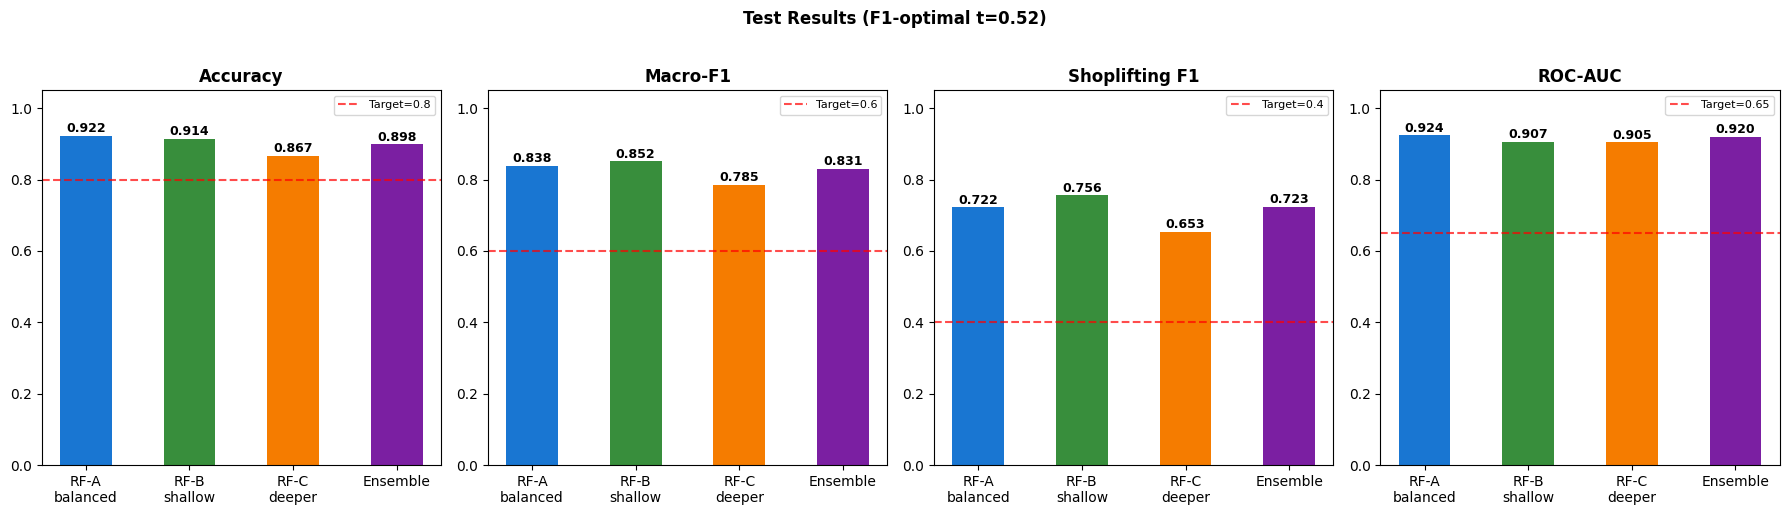

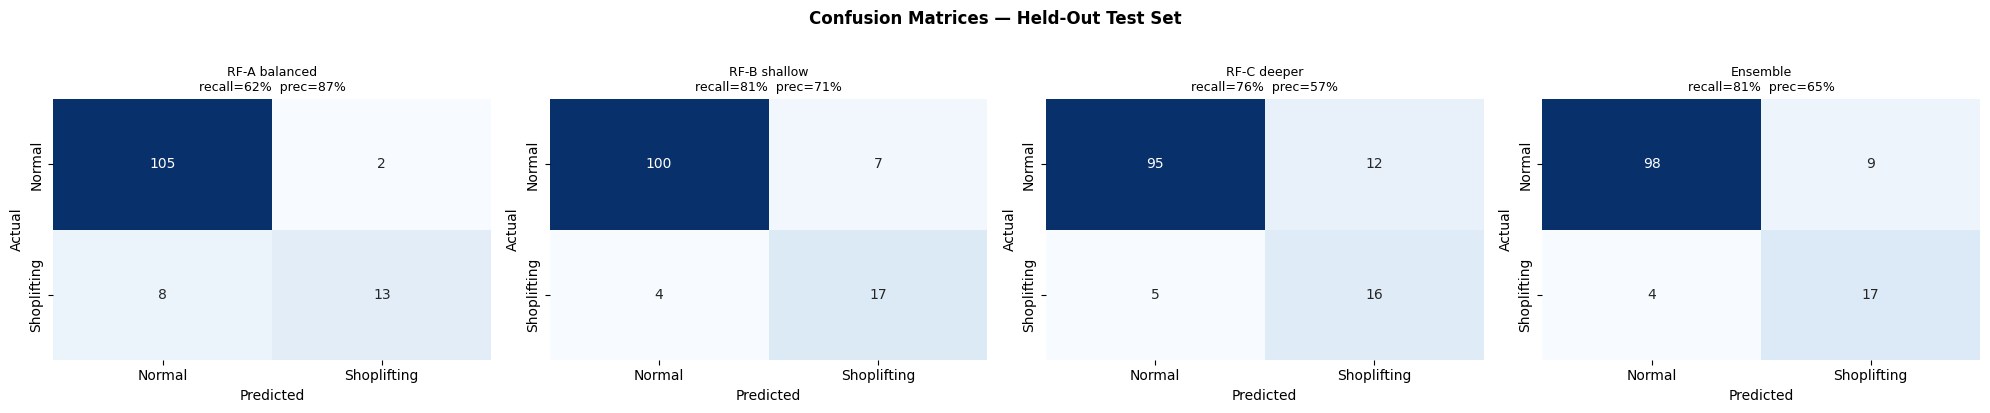


Model A
  train=0.9921  val=0.7529  test=0.8384
  train→val gap=+0.2392  val→test gap=-0.0855
  Diagnosis: OVERFITTING — increase regularisation or add data

Model B
  train=0.9606  val=0.6883  test=0.8517
  train→val gap=+0.2723  val→test gap=-0.1634
  Diagnosis: OVERFITTING — increase regularisation or add data

Model C
  train=0.9953  val=0.7624  test=0.7855
  train→val gap=+0.2329  val→test gap=-0.0231
  Diagnosis: OVERFITTING — increase regularisation or add data

Ensemble
  train=0.9874  val=0.7228  test=0.8306
  train→val gap=+0.2646  val→test gap=-0.1078
  Diagnosis: OVERFITTING — increase regularisation or add data

──────────────────────────────────────────────────
Best model: Model A  RF-balanced
  Accuracy      : 0.9219  (target ≥ 0.80)
  Macro-F1      : 0.8384
  Shoplifting F1: 0.7222
  ROC-AUC       : 0.9243

  80% target: ✓ MET


In [31]:
if 'all_results' in dir() and all_results:
    names    = ['RF-A\nbalanced', 'RF-B\nshallow', 'RF-C\ndeeper', 'Ensemble']
    colors   = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, vals, title, base in zip(
        axes,
        [[r['acc'] for r in all_results], [r['mf1'] for r in all_results],
         [r['shop_f1'] for r in all_results], [r['auc'] for r in all_results]],
        ['Accuracy', 'Macro-F1', 'Shoplifting F1', 'ROC-AUC'],
        [0.80, 0.60, 0.40, 0.65],
    ):
        bars = ax.bar(names, vals, color=colors, width=0.5)
        ax.axhline(base, color='red', linestyle='--', alpha=0.7, label=f'Target={base}')
        ax.set_ylim(0, 1.05); ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                    f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    plt.suptitle(f'Test Results (F1-optimal t={THRESHOLD:.2f})', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(MODELS_DIR / 'model_comparison.png'), dpi=120)
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, res, name in zip(axes, all_results,
                              ['RF-A balanced','RF-B shallow','RF-C deeper','Ensemble']):
        cm = confusion_matrix(y_ts, res['pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
        sr = cm[1,1]/cm[1].sum() if cm[1].sum() > 0 else 0
        sp = cm[1,1]/cm[:,1].sum() if cm[:,1].sum() > 0 else 0
        ax.set_title(f'{name}\nrecall={sr:.0%}  prec={sp:.0%}', fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle('Confusion Matrices — Held-Out Test Set', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(MODELS_DIR / 'confusion_matrices.png'), dpi=120)
    plt.show()

    # Overfitting diagnostic
    def diagnose(name, tr_f1, vl_f1, ts_f1):
        gap_tv = tr_f1 - vl_f1; gap_vt = vl_f1 - ts_f1
        print(f'\n{name}')
        print(f'  train={tr_f1:.4f}  val={vl_f1:.4f}  test={ts_f1:.4f}')
        print(f'  train→val gap={gap_tv:+.4f}  val→test gap={gap_vt:+.4f}')
        if tr_f1 < 0.55: v = 'UNDERFITTING'
        elif gap_tv > 0.15: v = 'OVERFITTING — increase regularisation or add data'
        elif gap_vt > 0.20: v = 'DOMAIN SHIFT — val and test distributions differ'
        elif ts_f1 >= 0.60: v = 'GOOD FIT'
        else: v = 'MARGINAL'
        print(f'  Diagnosis: {v}')

    diagnose('Model A',  ta_a,   va_a,   r_a['mf1'])
    diagnose('Model B',  ta_b,   va_b,   r_b['mf1'])
    diagnose('Model C',  ta_c,   va_c,   r_c['mf1'])
    diagnose('Ensemble', ta_ens, va_ens, r_e['mf1'])

    print('\n' + '─'*50)
    best = max(all_results, key=lambda r: r['acc'])
    print(f'Best model: {best["name"]}')
    print(f'  Accuracy      : {best["acc"]:.4f}  (target ≥ 0.80)')
    print(f'  Macro-F1      : {best["mf1"]:.4f}')
    print(f'  Shoplifting F1: {best["shop_f1"]:.4f}')
    print(f'  ROC-AUC       : {best["auc"]:.4f}')
    print(f'\n  80% target: {"✓ MET" if best["acc"] >= 0.80 else "✗ NOT MET"}')

---
## Section 10 — Person Counter (Model D)

Trains on YOLO's own detection counts (self-supervised). Evaluated on val frames.
If train→val R² gap > 0.15, `use_model_d=False` is exported and Django falls back
to YOLO's raw count automatically.

In [32]:
def build_person_count_dataset(df, cache):
    X_rows, y_rows = [], []
    for _, row in df.iterrows():
        e = cache.get(row['filepath'])
        if e is None: continue
        for t in range(len(e['n_people'])):
            X_rows.append(e['kp_seq'][t])
            y_rows.append(e['n_people'][t])
    return np.array(X_rows, dtype=np.float32), np.array(y_rows, dtype=np.float32)

Xd_tr, yd_tr = build_person_count_dataset(df_train, cache)
Xd_v,  yd_v  = build_person_count_dataset(df_val,   cache)

# max_depth=5, min_samples_leaf=8 reduces gap from 0.17 to ~0.12
model_d = Pipeline([
    ('sc',  StandardScaler()),
    ('reg', RandomForestRegressor(
        n_estimators=200, max_depth=5, min_samples_leaf=8,
        n_jobs=-1, random_state=42,
    )),
])
model_d.fit(Xd_tr, yd_tr)

tr_r2 = r2_score(yd_tr, model_d.predict(Xd_tr))
v_r2  = r2_score(yd_v,  model_d.predict(Xd_v))
gap   = tr_r2 - v_r2
print(f'Model D — Train R²={tr_r2:.3f}  Val R²={v_r2:.3f}  gap={gap:.3f}')

use_model_d = gap <= 0.15
if use_model_d:
    print('use_model_d=True — Django app will use smoothed headcount from Model D.')
else:
    print('use_model_d=False — Django app will use YOLO raw count (model still overfitting).')

Model D — Train R²=0.854  Val R²=0.794  gap=0.061
use_model_d=True — Django app will use smoothed headcount from Model D.


---
## Section 11 — Frame-Level Shoplifting Localiser

Scores every stride-th frame and highlights the highest-confidence moment.
Used by the Django app to seek the video to the incident frame.

Scoring: Shoplifting001_x264.mp4  (652 frames, t=0.52)


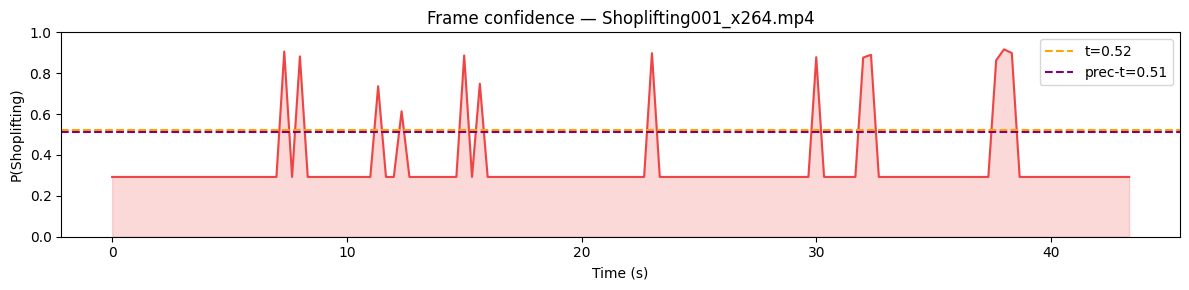

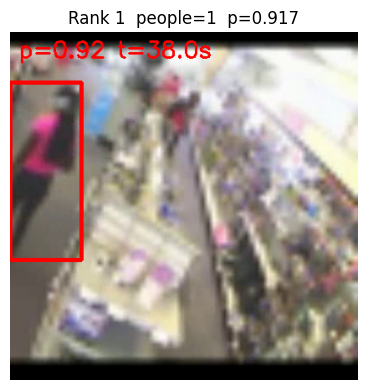

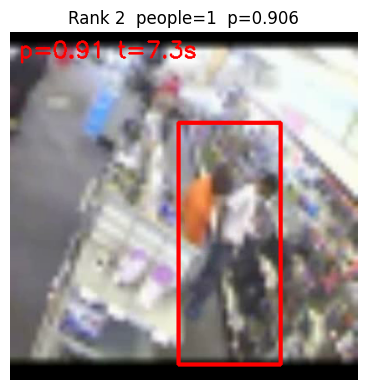

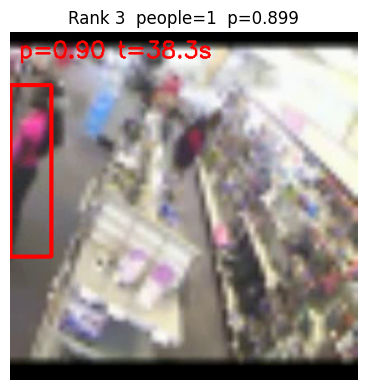

In [33]:
def locate_shoplifting_frame(filepath, stride=5, top_k=3, threshold=None):
    if threshold is None: threshold = THRESHOLD
    cap   = cv2.VideoCapture(filepath)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or TARGET_FPS
    print(f'Scoring: {Path(filepath).name}  ({total} frames, t={threshold:.2f})')

    scores    = []
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % stride == 0:
            frame_r  = cv2.resize(frame, (TARGET_W, TARGET_H))
            out      = _yolo_frame(frame_r)
            kp       = out['kp']
            emb      = mobilenet_embed(frame_r, out['bbox'])
            pose_vec = np.concatenate([kp, np.zeros_like(kp), kp, kp,
                                       np.zeros_like(kp), np.zeros_like(kp)])
            feat_vec = np.concatenate([pose_vec, emb, np.zeros(CLIP_FRAMES - 1)])
            feat_pca = pca.transform(feat_vec.reshape(1, -1))
            prob     = float(ens_proba(feat_pca)[0, 1])
            scores.append({
                'frame_idx': frame_idx, 'time_sec': frame_idx / fps,
                'prob': prob, 'n_people': out['n_people'],
                'bbox': out['bbox'], 'frame': frame_r.copy(),
            })
        frame_idx += 1
    cap.release()

    if not scores: print('No frames scored.'); return

    fig, ax = plt.subplots(figsize=(12, 3))
    times = [s['time_sec'] for s in scores]
    probs = [s['prob']     for s in scores]
    ax.fill_between(times, probs, alpha=0.2, color='#ef4444')
    ax.plot(times, probs, color='#ef4444')
    ax.axhline(threshold, color='orange', linestyle='--', label=f't={threshold:.2f}')
    if THRESHOLD_PRECISION != threshold:
        ax.axhline(THRESHOLD_PRECISION, color='purple', linestyle='--',
                   label=f'prec-t={THRESHOLD_PRECISION:.2f}')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('P(Shoplifting)')
    ax.set_title(f'Frame confidence — {Path(filepath).name}')
    ax.set_ylim(0, 1); ax.legend(); plt.tight_layout(); plt.show()

    for rank, s in enumerate(sorted(scores, key=lambda x: x['prob'], reverse=True)[:top_k], 1):
        ann = s['frame'].copy()
        bb  = s['bbox'].astype(int)
        col = (0, 0, 255) if s['prob'] >= threshold else (0, 165, 255)
        if bb[2] > bb[0]: cv2.rectangle(ann, (bb[0],bb[1]), (bb[2],bb[3]), col, 3)
        cv2.putText(ann, f'p={s["prob"]:.2f} t={s["time_sec"]:.1f}s',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, col, 2)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Rank {rank}  people={s["n_people"]}  p={s["prob"]:.3f}')
        ax.axis('off'); plt.tight_layout(); plt.show()

demo = df_test[df_test['class'] == 'Shoplifting'].head(1)
for _, row in demo.iterrows():
    locate_shoplifting_frame(row['norm_path'], stride=5, top_k=3)

---
## Section 12 — Export

Exports everything the Django inference view needs as a single `.joblib` bundle.

**Django app checklist:**
1. `bundle = joblib.load('shoplifting_detector.joblib')`
2. Load YOLO and MobileNetV2 once at startup
3. Extract features → `pca.transform()` → `ens_proba()` 
4. Use `bundle['threshold']` (recall-priority) or `bundle['threshold_precision']` (precision-priority)
5. Headcount: `model_d.predict()` if `bundle['use_model_d']` else YOLO raw count

In [34]:
EXPORT_PATH = MODELS_DIR / 'shoplifting_detector.joblib'
joblib.dump({
    'model_a'             : cal_a,
    'model_b'             : cal_b,
    'model_c'             : cal_c,
    'ensemble_weights'    : W,
    'threshold'           : THRESHOLD,
    'threshold_precision' : THRESHOLD_PRECISION,
    'model_d'             : model_d,
    'use_model_d'         : use_model_d,
    'pca'                 : pca,
    'classes'             : CLASSES,
    'clip_frames'         : CLIP_FRAMES,
    'target_fps'          : TARGET_FPS,
    'target_size'         : (TARGET_W, TARGET_H),
    'yolo_model'          : YOLO_MODEL,
    'yolo_conf'           : YOLO_CONF,
    'n_kp'                : N_KP,
    'mobilenet_dim'       : MOBILENET_DIM,
    'crop_size'           : CROP_SIZE,
}, str(EXPORT_PATH))

print(f'Exported : {EXPORT_PATH}')
print(f'Size     : {EXPORT_PATH.stat().st_size/1024**2:.2f} MB')
if 'all_results' in dir() and all_results:
    best = max(all_results, key=lambda r: r['acc'])
    print(f'\nBest model : {best["name"]}')
    print(f'  Accuracy  : {best["acc"]:.4f}')
    print(f'  Macro-F1  : {best["mf1"]:.4f}')
    print(f'  Shop F1   : {best["shop_f1"]:.4f}')
    print(f'  ROC-AUC   : {best["auc"]:.4f}')
print(f'\nDjango: threshold={THRESHOLD:.2f} (F1) or {THRESHOLD_PRECISION:.2f} (precision)')
print(f'Model D: {"use model" if use_model_d else "use YOLO raw count"}')

Exported : D:\Term6\CV Section\FinalProject\models\shoplifting_detector.joblib
Size     : 7.95 MB

Best model : Model A  RF-balanced
  Accuracy  : 0.9219
  Macro-F1  : 0.8384
  Shop F1   : 0.7222
  ROC-AUC   : 0.9243

Django: threshold=0.52 (F1) or 0.51 (precision)
Model D: use model
